In [39]:
import matplotlib.pyplot as plt
import pandas as pd
from seaborn import color_palette

In [40]:
df = pd.read_excel("income.xlsx", names=["name", "age", "income"])
df.head()


,name,age,income
0,Rob,29,45
1,Andrea,50,80
2,Mohan,35,52
3,Michael,32,41
4,Kory,36,87


In [41]:
import seaborn as sns

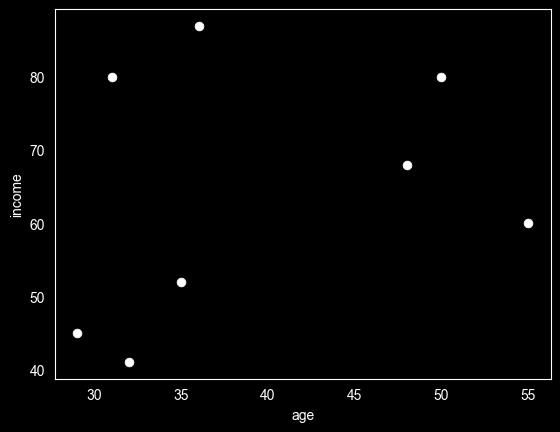

In [42]:
sns.scatterplot(data=df, x="age", y="income", color="white", s=40)
plt.grid(False)

## Implement Hierarchical Clustering

In [43]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=3, linkage="average")
hc.fit(df[["age", "income"]])
hc.labels_

array([1, 0, 1, 1, 2, 0, 2, 0])

In [44]:
df["cluster"] = hc.labels_
df

,name,age,income,cluster
0,Rob,29,45,1
1,Andrea,50,80,0
2,Mohan,35,52,1
3,Michael,32,41,1
4,Kory,36,87,2
5,David,48,68,0
6,Ismail,31,80,2
7,Sheela,55,60,0


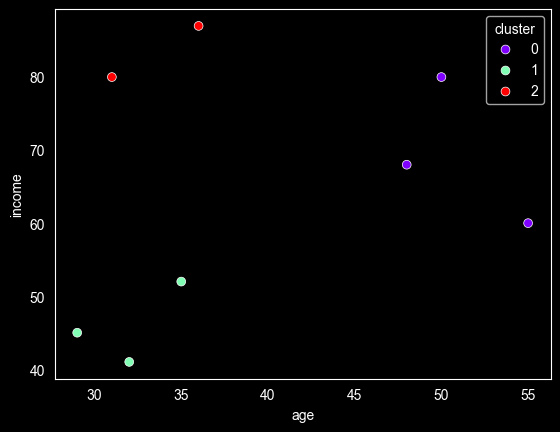

In [45]:
sns.scatterplot(data=df, x="age", y="income", hue="cluster",palette="rainbow", s=40)
plt.grid(False)


## implement HC by Scipy

In [46]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
X = df[["age", "income"]]
z = linkage(X, method="average")
z

array([[ 0.        ,  3.        ,  5.        ,  2.        ],
       [ 4.        ,  6.        ,  8.60232527,  2.        ],
       [ 2.        ,  8.        , 10.31064935,  3.        ],
       [ 5.        ,  7.        , 10.63014581,  2.        ],
       [ 1.        , 11.        , 16.39052659,  3.        ],
       [ 9.        , 12.        , 23.69824661,  5.        ],
       [10.        , 13.        , 33.65863823,  8.        ]])

## Example of Euclidean Distance

In [55]:
import numpy as np
np.sqrt((29-32)**2 + (45-41)**2)

np.float64(5.0)

## Implement Dendrogram

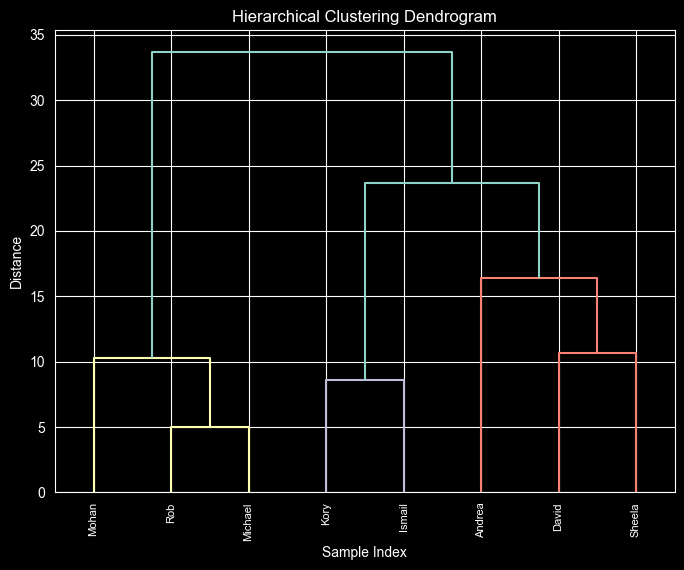

In [49]:
plt.figure(figsize=(8, 6))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
dendrogram(z, labels=df["name"].values, leaf_rotation=90, leaf_font_size=8)
plt.grid(True)
plt.show()

In [58]:
clusters = fcluster(z, t = 3, criterion="maxclust")
clusters

array([1, 3, 1, 1, 2, 3, 2, 3], dtype=int32)

In [59]:
df["cluster"] = clusters

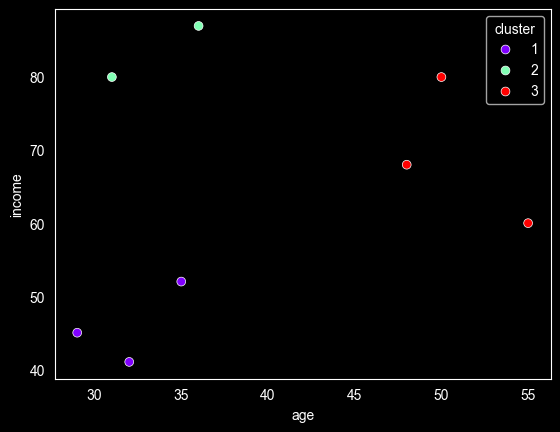

In [60]:
sns.scatterplot(data=df, x="age", y="income", hue="cluster",palette="rainbow", s=40)
plt.grid(False)
